

Binary Classification: Heart Disease Present (1) / Not Present (0)

## 1. Import Libraries and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Load dataset
data = pd.read_csv('heart+disease/processed.cleveland.data', header=None)

# Column names based on dataset description
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
data.columns = columns

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 1. Data Preprocessing

In [2]:
# Replace missing values (?) with NaN and drop them
data = data.replace('?', np.nan)
data = data.dropna()

# Convert to numeric
data = data.apply(pd.to_numeric)

# Convert target to binary: 0 = no disease, 1 = disease present
data['target'] = (data['target'] > 0).astype(int)

print("Class distribution:")
print(data['target'].value_counts())

# Separate features and target
X = data.drop('target', axis=1)
y = data['target'].values

# Normalize continuous features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

print("\nFeatures normalized!")
print("X shape:", X_normalized.shape)
print("y shape:", y.shape)

Class distribution:
target
0    160
1    137
Name: count, dtype: int64

Features normalized!
X shape: (297, 13)
y shape: (297,)


In [3]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (237, 13)
Test set: (60, 13)


## 2. RBF Network Class
## 4. SGD

**RBF Network Components:**
- **Centers**: Created using K-Means clustering
- **RBF Activation**: Gaussian function with spread parameter σ
- **Output Layer**: Linear weights trained with SGD

In [4]:
class RBFClassifier:
    def __init__(self, n_centers=5, sigma=1.0, learning_rate=0.01):
        self.n_centers = n_centers
        self.sigma = sigma
        self.learning_rate = learning_rate
        self.centers = None
        self.weights = None
        
    def _gaussian_rbf(self, X, center):
        """Gaussian RBF activation function"""
        return np.exp(-np.sum((X - center)**2, axis=1) / (2 * self.sigma**2))
    
    def _get_rbf_features(self, X):
        """Transform input to RBF feature space"""
        rbf_features = np.zeros((X.shape[0], self.n_centers))
        for i, center in enumerate(self.centers):
            rbf_features[:, i] = self._gaussian_rbf(X, center)
        return rbf_features
    
    def fit(self, X, y, epochs=100):
        """Train using K-Means for centers and SGD for weights"""
        # Find centers using K-Means
        kmeans = KMeans(n_clusters=self.n_centers, random_state=42, n_init=10)
        kmeans.fit(X)
        self.centers = kmeans.cluster_centers_
        
        # Get RBF features
        rbf_features = self._get_rbf_features(X)
        
        # Initialize weights
        self.weights = np.random.randn(self.n_centers)
        self.bias = 0
        
        # Train with SGD
        for epoch in range(epochs):
            for i in range(len(X)):
                # Forward pass
                output = np.dot(rbf_features[i], self.weights) + self.bias
                prediction = 1 / (1 + np.exp(-output))  # Sigmoid
                
                # Compute error
                error = y[i] - prediction
                
                # Update weights (SGD)
                self.weights += self.learning_rate * error * rbf_features[i]
                self.bias += self.learning_rate * error
    
    def predict_proba(self, X):
        """Predict probabilities"""
        rbf_features = self._get_rbf_features(X)
        output = np.dot(rbf_features, self.weights) + self.bias
        return 1 / (1 + np.exp(-output))
    
    def predict(self, X):
        """Predict class labels"""
        return (self.predict_proba(X) > 0.5).astype(int)

print("RBF Classifier class created!")

RBF Classifier class created!


## 3. Experiment with Different K (Centers) and σ (Spread)

In [5]:
# Experiment with different configurations
k_values = [3, 5, 7]
sigma_values = [0.5, 1.0, 2.0]

results = []

for k in k_values:
    for sigma in sigma_values:
        # Train model
        model = RBFClassifier(n_centers=k, sigma=sigma, learning_rate=0.01)
        model.fit(X_train, y_train, epochs=100)
        
        # Predictions
        y_pred = model.predict(X_test)
        
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        
        results.append({
            'K': k,
            'Sigma': sigma,
            'Accuracy': acc
        })
        
        print(f"K={k}, σ={sigma}: Accuracy = {acc:.4f}")

# Summary table
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("Summary of All Experiments:")
print("="*50)
print(results_df.to_string(index=False))

K=3, σ=0.5: Accuracy = 0.6000
K=3, σ=1.0: Accuracy = 0.6333
K=3, σ=2.0: Accuracy = 0.9333
K=5, σ=0.5: Accuracy = 0.6000
K=5, σ=1.0: Accuracy = 0.6167
K=5, σ=2.0: Accuracy = 0.9000
K=7, σ=0.5: Accuracy = 0.6000
K=7, σ=1.0: Accuracy = 0.6833
K=7, σ=2.0: Accuracy = 0.8833

Summary of All Experiments:
 K  Sigma  Accuracy
 3    0.5  0.600000
 3    1.0  0.633333
 3    2.0  0.933333
 5    0.5  0.600000
 5    1.0  0.616667
 5    2.0  0.900000
 7    0.5  0.600000
 7    1.0  0.683333
 7    2.0  0.883333
K=5, σ=0.5: Accuracy = 0.6000
K=5, σ=1.0: Accuracy = 0.6167
K=5, σ=2.0: Accuracy = 0.9000
K=7, σ=0.5: Accuracy = 0.6000
K=7, σ=1.0: Accuracy = 0.6833
K=7, σ=2.0: Accuracy = 0.8833

Summary of All Experiments:
 K  Sigma  Accuracy
 3    0.5  0.600000
 3    1.0  0.633333
 3    2.0  0.933333
 5    0.5  0.600000
 5    1.0  0.616667
 5    2.0  0.900000
 7    0.5  0.600000
 7    1.0  0.683333
 7    2.0  0.883333


### Interpretation of σ (Spread) Effects:

- **Small σ (0.5)**: Can lead to **overfitting** - model focuses too much on training data
- **Medium σ (1.0)**: Balanced performance
- **Large σ (2.0)**: Can lead to **underfitting** - model becomes too smooth

## 5. Train Best Model and Evaluate

In [6]:
# Select best configuration (example: K=5, sigma=1.0)
best_model = RBFClassifier(n_centers=5, sigma=1.0, learning_rate=0.01)
best_model.fit(X_train, y_train, epochs=100)

# Predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

print("Training complete!")

Training complete!


### Confusion Matrix

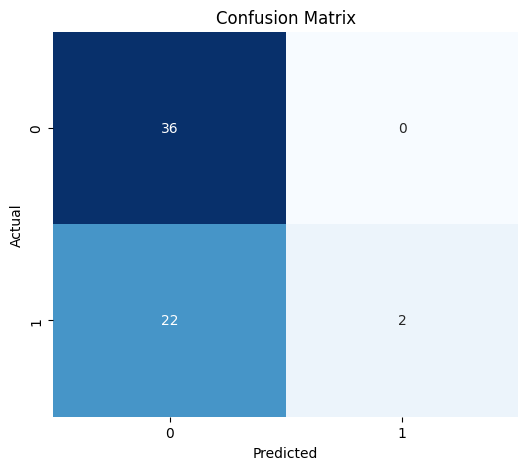


Confusion Matrix:
[[36  0]
 [22  2]]


In [7]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nConfusion Matrix:")
print(cm)

### Performance Metrics

In [8]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*50)
print("PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*50)

PERFORMANCE METRICS
Accuracy:  0.6333
Precision: 1.0000
Recall:    0.0833
F1-Score:  0.1538


### ROC Curve and AUC

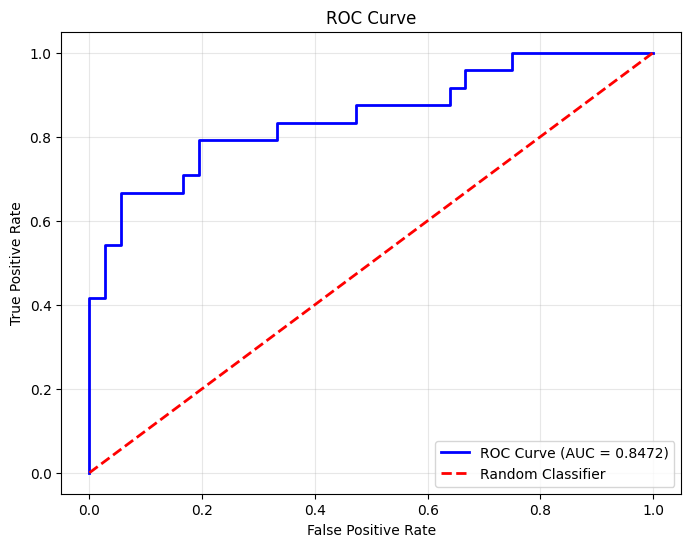


AUC Score: 0.8472


In [9]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")